We wish to compare the convergence time of the empirical average of the same  worst case function for different starting distributions $X_0 \sim \mu_0$. To do this, we simulate $\dot \Delta_n^2$ for $X_0 \sim \delta_{x_0} and for X_0 \sim \mu$

In [10]:
import numpy as np 
import matplotlib.pyplot as plt 
import mc

In [82]:
N = 4000
p_rational = 0.7 
p_irrational = 1/np.sqrt(2)
iteration_count = 70000
number_deltas = 300

In [73]:
m_1_rational, m_2_rational = mc.find_opt_int(N, p_rational, rational=True)
m_1_irrational, m_2_irrational = mc.find_opt_int(N, p_irrational)

In [74]:
print("Irrational m_1: ", m_1_irrational)
print("Irational m_2: ", m_2_irrational)
print("Rational m_1: ", m_1_rational)
print("Rational m_2: ", m_2_rational)

Irrational m_1:  3998
Irational m_2:  5
Rational m_1:  3997.0
Rational m_2:  7.0


In [83]:
dot_delta_n_rational = mc.compute_delta_paper(N, p_rational, m_1_rational, m_2_rational, number_deltas, iteration_count, dist="delta", xy_0=[N, N], squared=True) 
dot_delta_n_irrational = mc.compute_delta_paper(N, p_irrational, m_1_irrational, m_2_irrational, number_deltas, iteration_count, dist="delta", xy_0=[N, N], squared=True)

delta_n_rational = mc.compute_delta_paper(N, p_rational, m_1_rational, m_2_rational, number_deltas, iteration_count, squared=True)
delta_n_irrational = mc.compute_delta_paper(N, p_irrational, m_1_irrational, m_2_irrational, number_deltas, iteration_count, squared=True)


0.7
0.7071067811865475
0.7
0.7071067811865475


In [76]:
def ub(n, tau, mu_min):
    return 4 * tau/n * (1+1/mu_min)

In [57]:
tau = mc.compute_tau_cyclical(N, m_1_irrational, m_2_irrational, p_irrational)
upper_bound_delta = [ub(n, tau, 1/N**2) for n in range(40000, 50000)]
tau

np.float64(9299.632639027508)

\begin{equation}
\dot \Delta_n^2 \leq \frac{4 \tau}{n} + \frac{4\tau}{n^2} \frac{1}{\sqrt{\mu(x_0)\mu_{\min}}} \frac{1}{1 - e^{\frac{1}{4\tau^2}}}
\end{equation}

In [58]:
ub(70000, tau, 1/N**2)

np.float64(4782668.745764583)

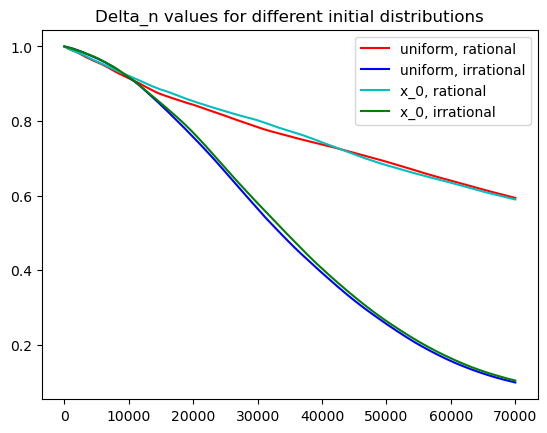

In [ ]:
plt.plot(range(iteration_count), delta_n_rational, c="r", label="uniform, rational")
plt.plot(range(iteration_count), delta_n_irrational, c="b", label="uniform, irrational")
plt.plot(range(iteration_count), dot_delta_n_rational, c="c", label="x_0, rational")
plt.plot(range(iteration_count), dot_delta_n_irrational, c="g", label="x_0, irrational")
#plt.plot(range(10000, iteration_count), np.concatenate(([0]*30000, upper_bound_delta), axis=0), c="y", label="upper-bound")

plt.title(f"Delta_n values for different initial distributions with {iteration_count} values and {number_deltas} delta runs averaged")
plt.legend()